# COCO Multi-Label Classification with ConvGist

This notebook trains a ConvGist model for multi-label classification on the COCO dataset.
The pipeline:
1. Extract Gist features from images
2. Train ConvGist with linear classifier for multi-label classification

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

from gist import Gist
from backbone import ConvGist
from dataset_handler import COCODatasetHandler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or b

Using device: cuda


## 1. Dataset Setup

In [3]:
# COCO dataset paths
COCO_ROOT = r"/home/julian/Projects/KEMAI/CoCo/"

# Training hyperparameters
BATCH_SIZE = 64  # Reduced from 256 - better for small models
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
IMG_SIZE = 256

CONVGIST_WEIGHTS_PATH = "best_convgist_model.pth"

In [4]:
class COCOMultiLabelDataset(Dataset):
    """COCO dataset for multi-label classification."""
    
    def __init__(self, coco_handler, transform=None, max_samples=None):
        """
        Args:
            coco_handler: COCODatasetHandler instance
            transform: torchvision transforms for images
            max_samples: Limit number of samples (for valing)
        """
        self.coco_handler = coco_handler
        self.coco = coco_handler.coco
        self.transform = transform
        
        # Get all image IDs
        self.img_ids = self.coco.getImgIds()
        if max_samples:
            self.img_ids = self.img_ids[:max_samples]
        
        # Get all category IDs and create mapping
        self.cat_ids = self.coco.getCatIds()
        self.cat_id_to_idx = {cat_id: idx for idx, cat_id in enumerate(self.cat_ids)}
        self.num_classes = len(self.cat_ids)
        
        print(f"Dataset initialized with {len(self.img_ids)} images and {self.num_classes} classes")
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        
        # Load image as grayscale
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.coco_handler.dataset.root, img_info['file_name'])
        image = Image.open(img_path).convert('L')  # Convert to grayscale
        
        # Get annotations for this image
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        
        # Create multi-label target
        label = torch.zeros(self.num_classes, dtype=torch.float32)
        for ann in anns:
            cat_id = ann['category_id']
            if cat_id in self.cat_id_to_idx:
                label[self.cat_id_to_idx[cat_id]] = 1.0
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [5]:
# Initialize COCO dataset handlers for train and val
coco_handler_train = COCODatasetHandler(COCO_ROOT, "train2017")
coco_handler_val = COCODatasetHandler(COCO_ROOT, "val2017")

# Define transforms
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Create datasets
train_dataset = COCOMultiLabelDataset(coco_handler_train, transform=transform, max_samples=120000)
val_dataset = COCOMultiLabelDataset(coco_handler_val, transform=transform, max_samples=10000)

# Create dataloaders
# On Windows, num_workers > 0 can cause significant overhead due to process spawning
# Using num_workers=0 (single-threaded) is often faster on Windows
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=15,
    pin_memory=True   # Keep pin_memory for faster GPU transfer
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=5,  # Single-threaded
    pin_memory=True
)

print(f"Train samples: {len(train_dataset)}, val samples: {len(val_dataset)}")
print(f"Batch size: {BATCH_SIZE}")

loading annotations into memory...
Done (t=7.14s)
creating index...
index created!
loading annotations into memory...
Done (t=0.33s)
creating index...
index created!
Dataset initialized with 118287 images and 80 classes
Dataset initialized with 5000 images and 80 classes
Train samples: 118287, val samples: 5000
Batch size: 64


/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 15 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 2. Model Setup

We create a pipeline with:
1. **Gist model** (feature extractor with default parameters)
2. **ConvGist model** (with linear classifier for multi-label classification)

In [6]:
# Create Gist model without flattening for ConvGist input (1 channel for grayscale)
# This matches the reference notebook configuration
gist_model = Gist(
    in_channels=1,
    stride=4,
    pooling=None,  # NO pooling to maintain 64x64 spatial resolution
    flatten=False
)
gist_model.eval()
gist_model.to(device)

for param in gist_model.parameters():
    param.requires_grad = False

# Get output shape
with torch.no_grad():
    dummy_input = torch.randn(1, 1, IMG_SIZE, IMG_SIZE).to(device)  # 1 channel for grayscale
    gist_features = gist_model(dummy_input)
    print(f"Gist features shape (unflattened): {gist_features.shape}")
    gist_channels = gist_features.shape[1]
    
    # Expected: (1, 49, 64, 64) or similar
    # With defaults: 4 scales x 6 orientations x 2 phases + 1 Gaussian = 49 channels

print(f"Gist output channels: {gist_channels}")
print(f"Spatial dimensions: {gist_features.shape[2]}x{gist_features.shape[3]}")

Gist features shape (unflattened): torch.Size([1, 97, 64, 64])
Gist output channels: 97
Spatial dimensions: 64x64


In [7]:
# Initialize ConvGist model with linear classifier
num_classes = train_dataset.num_classes
convgist_model = ConvGist(
    in_channels=gist_channels,
    n_classes=num_classes,
    classifier="linear"
)
convgist_model.to(device)

print(f"ConvGist model initialized for {num_classes} classes")
print(f"ConvGist model: {convgist_model}")

ConvGist model initialized for 80 classes
ConvGist model: ConvGist(
  (classifier): Linear(in_features=512, out_features=80, bias=True)
  (features): Sequential(
    (0): BatchNorm2d(97, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Conv2d(97, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (2): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (5): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (8): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bia

In [8]:
if CONVGIST_WEIGHTS_PATH and os.path.exists(CONVGIST_WEIGHTS_PATH):
    print(f"Loading pre-trained Gist weights from {CONVGIST_WEIGHTS_PATH}")
    convgist_model.load_state_dict(torch.load(CONVGIST_WEIGHTS_PATH, map_location=device))
    print("Pre-trained Gist weights loaded successfully!")
else:
    print(f"No pre-trained Gist weights found")
    print("Using randomly initialized Gist model (default parameters)")

Loading pre-trained Gist weights from best_convgist_model.pth
Pre-trained Gist weights loaded successfully!


In [9]:
# Inspect internal dimensions of ConvGist model at each processing step
print("\n" + "="*80)
print("CONVGIST MODEL INTERNAL DIMENSIONS")
print("="*80)

# Create a dummy input (Gist features)
with torch.no_grad():
    dummy_gist_input = torch.randn(1, gist_channels, 8, 8).to(device)
    
    print(f"\nInput to ConvGist (Gist features): {dummy_gist_input.shape}")
    print(f"  - Batch size: {dummy_gist_input.shape[0]}")
    print(f"  - Channels: {dummy_gist_input.shape[1]} (Gist feature channels)")
    print(f"  - Spatial: {dummy_gist_input.shape[2]}x{dummy_gist_input.shape[3]}")
    
    # Manually pass through each layer in the features sequential module
    x = dummy_gist_input
    print("\n" + "-"*80)
    print("Processing through ConvGist feature extractor:")
    print("-"*80)
    
    for i, layer in enumerate(convgist_model.features):
        layer_name = layer.__class__.__name__
        
        # Format layer description
        if isinstance(layer, nn.Conv2d):
            layer_desc = f"{layer_name}(in={layer.in_channels}, out={layer.out_channels}, kernel={layer.kernel_size}, stride={layer.stride})"
        elif isinstance(layer, nn.BatchNorm2d) or isinstance(layer, nn.InstanceNorm2d):
            layer_desc = f"{layer_name}(channels={layer.num_features})"
            continue
        elif isinstance(layer, nn.AdaptiveAvgPool2d):
            layer_desc = f"{layer_name}(output_size={layer.output_size})"
        else:
            layer_desc = layer_name
        
        x = layer(x)
        print(f"\nLayer {i}: {layer_desc}")
        print(f"  Output shape: {x.shape}")
        
        # Additional info for spatial dimensions
        if len(x.shape) == 4:
            print(f"  - Channels: {x.shape[1]}, Spatial: {x.shape[2]}x{x.shape[3]}")
        elif len(x.shape) == 2:
            print(f"  - Features: {x.shape[1]}")
    
    # Pass through classifier
    final_output = convgist_model.classifier(x)
    print("\n" + "-"*80)
    print(f"Classifier (Linear): {convgist_model.classifier}")
    print(f"  Output shape: {final_output.shape}")
    print(f"  - Batch size: {final_output.shape[0]}")
    print(f"  - Classes: {final_output.shape[1]}")
    print("="*80)


CONVGIST MODEL INTERNAL DIMENSIONS

Input to ConvGist (Gist features): torch.Size([1, 97, 8, 8])
  - Batch size: 1
  - Channels: 97 (Gist feature channels)
  - Spatial: 8x8

--------------------------------------------------------------------------------
Processing through ConvGist feature extractor:
--------------------------------------------------------------------------------

Layer 1: Conv2d(in=97, out=128, kernel=(5, 5), stride=(2, 2))
  Output shape: torch.Size([1, 128, 4, 4])
  - Channels: 128, Spatial: 4x4

Layer 3: LeakyReLU
  Output shape: torch.Size([1, 128, 4, 4])
  - Channels: 128, Spatial: 4x4

Layer 4: Conv2d(in=128, out=256, kernel=(3, 3), stride=(2, 2))
  Output shape: torch.Size([1, 256, 2, 2])
  - Channels: 256, Spatial: 2x2

Layer 6: LeakyReLU
  Output shape: torch.Size([1, 256, 2, 2])
  - Channels: 256, Spatial: 2x2

Layer 7: Conv2d(in=256, out=512, kernel=(3, 3), stride=(2, 2))
  Output shape: torch.Size([1, 512, 1, 1])
  - Channels: 512, Spatial: 1x1

Layer 9: 

## 3. Training Setup

In [7]:
# Focal Loss for handling extreme class imbalance
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-label classification.
    Addresses class imbalance by down-weighting easy examples and focusing on hard ones.
    
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    
    Args:
        alpha: Weighting factor in [0, 1] to balance positive/negative examples
        gamma: Focusing parameter >= 0. gamma=0 is equivalent to BCE loss
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        """
        Args:
            inputs: (N, C) logits
            targets: (N, C) binary labels (0 or 1)
        """
        # Apply sigmoid to get probabilities
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        
        # Calculate focal term: (1 - p_t)^gamma
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - p_t) ** self.gamma
        
        # Apply alpha weighting
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        
        # Focal loss
        loss = alpha_t * focal_term * BCE_loss
        
        return loss.mean()

# Calculate class weights with capping to prevent extreme values
# print("Calculating class weights from training data...")
# all_train_labels = []
# for _, labels in train_loader:
#     all_train_labels.append(labels)
# all_train_labels = torch.cat(all_train_labels, dim=0)  # (N, 80)

# # Calculate positive rate per class
# pos_counts = all_train_labels.sum(dim=0)
# neg_counts = len(all_train_labels) - pos_counts
# pos_weight = neg_counts / (pos_counts + 1e-8)

# print(f"Class weight range before capping: [{pos_weight.min():.2f}, {pos_weight.max():.2f}]")
# print(f"Classes with weight > 100: {(pos_weight > 100).sum()}")

# # Cap weights to prevent extreme values
# pos_weight_capped = pos_weight.clamp(min=1.0, max=10.0)
# print(f"Class weight range after capping: [{pos_weight_capped.min():.2f}, {pos_weight_capped.max():.2f}]")

# Loss function: Use Focal Loss for better handling of class imbalance
# Focal loss parameters:
# - alpha=0.25: Slight weighting towards positive examples
# - gamma=2.0: Standard focusing parameter (down-weight easy examples)
criterion = FocalLoss(alpha=0.25, gamma=2.0)

# Alternative: Weighted BCE loss with capped weights (uncomment to use)
# pos_weight_capped = pos_weight_capped.to(device)
# criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_capped)

# Optimizer (only ConvGist parameters are trainable)
optimizer = optim.Adam(convgist_model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print(f"Loss function: Focal Loss (alpha={criterion.alpha}, gamma={criterion.gamma})")
print("Focal loss will focus on hard examples and down-weight easy negatives")

Loss function: Focal Loss (alpha=0.25, gamma=2.0)
Focal loss will focus on hard examples and down-weight easy negatives


/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 4. Training Loop

In [8]:
def train_epoch(model, gist_extractor, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    gist_extractor.eval()
    
    total_loss = 0.0
    
    for images, labels in tqdm(dataloader, desc="Training"):
        images = images.to(device)
        labels = labels.to(device)
        
        # Extract Gist features (no grad)
        with torch.no_grad():
            gist_features = gist_extractor(images)
        
        # Forward pass through ConvGist
        optimizer.zero_grad()
        outputs = model(gist_features)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate(model, gist_extractor, dataloader, criterion, device):
    """Validate the model with comprehensive metrics."""
    model.eval()
    gist_extractor.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)
            
            # Extract Gist features
            gist_features = gist_extractor(images)
            
            # Forward pass
            outputs = model(gist_features)
            
            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Store predictions, probabilities, and labels
            probs = torch.sigmoid(outputs)
            predictions = probs > 0.5
            all_predictions.append(predictions.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
    
    # Concatenate all batches
    all_predictions = torch.cat(all_predictions, dim=0)  # (N, 80)
    all_probs = torch.cat(all_probs, dim=0)  # (N, 80)
    all_labels = torch.cat(all_labels, dim=0)  # (N, 80)
    
    # Calculate per-sample metrics
    exact_match = (all_predictions == all_labels).all(dim=1).float().mean()
    hamming_acc = (all_predictions == all_labels).float().mean()
    
    # Calculate per-class metrics
    # True Positives, False Positives, False Negatives, True Negatives
    tp = ((all_predictions == 1) & (all_labels == 1)).sum(dim=0).float()
    fp = ((all_predictions == 1) & (all_labels == 0)).sum(dim=0).float()
    fn = ((all_predictions == 0) & (all_labels == 1)).sum(dim=0).float()
    tn = ((all_predictions == 0) & (all_labels == 0)).sum(dim=0).float()
    
    # Precision, Recall, F1 per class
    precision = tp / (tp + fp + 1e-8)  # Avoid division by zero
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    # Mean precision, recall, F1 (only over classes that appear in the dataset)
    classes_present = (all_labels.sum(dim=0) > 0)
    mean_precision = precision[classes_present].mean().item()
    mean_recall = recall[classes_present].mean().item()
    mean_f1 = f1[classes_present].mean().item()
    
    # Calculate mean Average Precision (mAP)
    # For each class, calculate AP
    aps = []
    for class_idx in range(all_labels.shape[1]):
        y_true = all_labels[:, class_idx].numpy()
        y_score = all_probs[:, class_idx].numpy()
        
        # Skip classes with no positive samples
        if y_true.sum() == 0:
            continue
        
        # Sort by predicted probability (descending)
        sorted_indices = np.argsort(-y_score)
        y_true_sorted = y_true[sorted_indices]
        
        # Calculate precision at each threshold
        tp_cumsum = np.cumsum(y_true_sorted)
        precision_curve = tp_cumsum / np.arange(1, len(y_true_sorted) + 1)
        
        # Average Precision (area under precision-recall curve)
        ap = np.sum(precision_curve * y_true_sorted) / y_true.sum()
        aps.append(ap)
    
    mean_ap = np.mean(aps) if len(aps) > 0 else 0.0
    
    metrics = {
        'loss': total_loss / len(dataloader),
        'exact_match': exact_match.item(),
        'hamming_acc': hamming_acc.item(),
        'precision': mean_precision,
        'recall': mean_recall,
        'f1': mean_f1,
        'mAP': mean_ap,
        'per_class_precision': precision,
        'per_class_recall': recall,
        'per_class_f1': f1,
        'classes_present': classes_present,
    }
    
    return metrics

In [9]:
# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_exact_match': [],
    'val_hamming_acc': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_mAP': [],
}

best_val_loss = float('inf')
best_val_mAP = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    
    # Train
    train_loss = train_epoch(convgist_model, gist_model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_metrics = validate(convgist_model, gist_model, val_loader, criterion, device)
    
    # Update history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_exact_match'].append(val_metrics['exact_match'])
    history['val_hamming_acc'].append(val_metrics['hamming_acc'])
    history['val_precision'].append(val_metrics['precision'])
    history['val_recall'].append(val_metrics['recall'])
    history['val_f1'].append(val_metrics['f1'])
    history['val_mAP'].append(val_metrics['mAP'])
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f} | Exact Match: {val_metrics['exact_match']:.4f} | Hamming Acc: {val_metrics['hamming_acc']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f} | F1: {val_metrics['f1']:.4f} | mAP: {val_metrics['mAP']:.4f}")
    
    # Learning rate scheduling
    scheduler.step(val_metrics['loss'])
    
    # Save best model based on mAP
    if val_metrics['mAP'] > best_val_mAP:
        best_val_mAP = val_metrics['mAP']
        torch.save(convgist_model.state_dict(), 'best_convgist_model.pth')
        print(f"Saved best model (mAP: {best_val_mAP:.4f})")
    
# Store final per-class metrics for analysis
final_per_class_metrics = {
    'precision': val_metrics['per_class_precision'],
    'recall': val_metrics['per_class_recall'],
    'f1': val_metrics['per_class_f1'],
    'classes_present': val_metrics['classes_present'],
}


Epoch 1/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.34it/s]


Train Loss: 0.0125
Val Loss: 0.0112 | Exact Match: 0.0098 | Hamming Acc: 0.9641
Precision: 0.0118 | Recall: 0.0014 | F1: 0.0025 | mAP: 0.1699
Saved best model (mAP: 0.1699)

Epoch 2/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.49it/s]


Train Loss: 0.0107
Val Loss: 0.0106 | Exact Match: 0.0130 | Hamming Acc: 0.9654
Precision: 0.0447 | Recall: 0.0064 | F1: 0.0103 | mAP: 0.2275
Saved best model (mAP: 0.2275)

Epoch 3/20


...

Train Loss: 0.0068
Val Loss: 0.0091 | Exact Match: 0.0774 | Hamming Acc: 0.9696
Precision: 0.5104 | Recall: 0.0953 | F1: 0.1429 | mAP: 0.3705

Epoch 19/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.44it/s]


Train Loss: 0.0067
Val Loss: 0.0093 | Exact Match: 0.0782 | Hamming Acc: 0.9696
Precision: 0.5033 | Recall: 0.0908 | F1: 0.1353 | mAP: 0.3683

Epoch 20/20


Validation: 100%|██████████| 79/79 [00:12<00:00,  6.45it/s]

Train Loss: 0.0066
Val Loss: 0.0091 | Exact Match: 0.0796 | Hamming Acc: 0.9695
Precision: 0.5232 | Recall: 0.0926 | F1: 0.1393 | mAP: 0.3700


## 5. Visualize Results

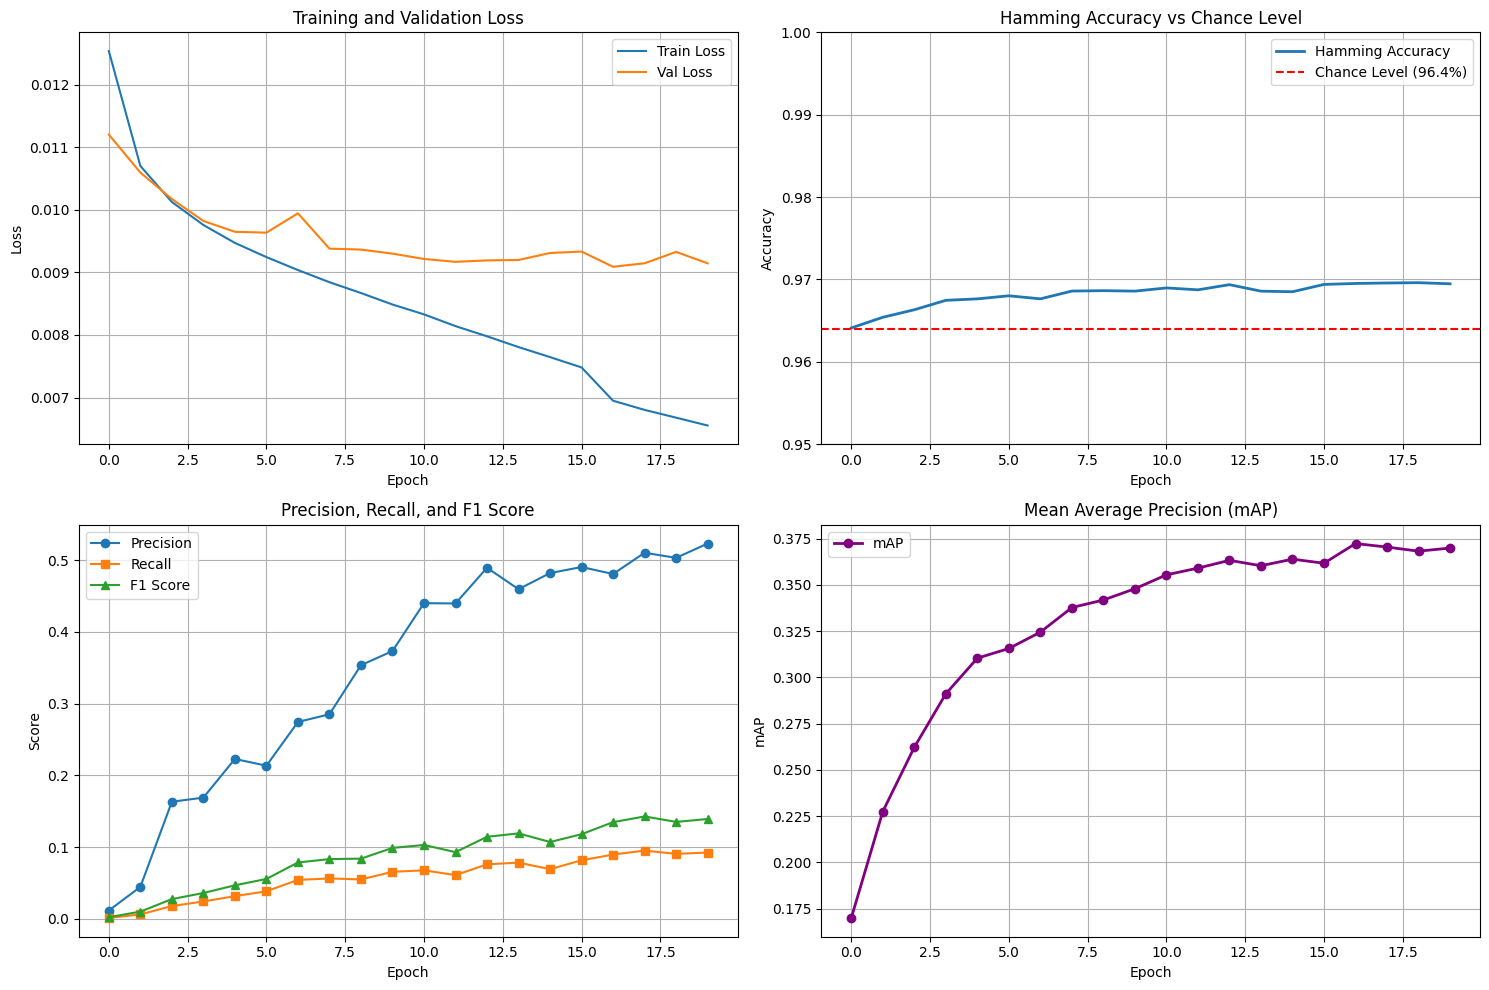

In [10]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Hamming Accuracy vs Chance Level
axes[0, 1].plot(history['val_hamming_acc'], label='Hamming Accuracy', linewidth=2)
axes[0, 1].axhline(y=0.964, color='r', linestyle='--', label='Chance Level (96.4%)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Hamming Accuracy vs Chance Level')
axes[0, 1].legend()
axes[0, 1].grid(True)
axes[0, 1].set_ylim([0.95, 1.0])

# Precision, Recall, F1
axes[1, 0].plot(history['val_precision'], label='Precision', marker='o')
axes[1, 0].plot(history['val_recall'], label='Recall', marker='s')
axes[1, 0].plot(history['val_f1'], label='F1 Score', marker='^')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Precision, Recall, and F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

# mAP
axes[1, 1].plot(history['val_mAP'], label='mAP', marker='o', linewidth=2, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('mAP')
axes[1, 1].set_title('Mean Average Precision (mAP)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

## 6. Per-Class Performance Analysis

In [11]:
# Analyze per-class performance
categories = coco_handler_val.coco.loadCats(coco_handler_val.coco.getCatIds())
cat_id_to_name = {cat['id']: cat['name'] for cat in categories}
idx_to_cat_id = {idx: cat_id for cat_id, idx in val_dataset.cat_id_to_idx.items()}

# Get class names in order
class_names = [cat_id_to_name[idx_to_cat_id[i]] for i in range(len(idx_to_cat_id))]

# Get metrics for classes that were present in validation set
precision = final_per_class_metrics['precision'].numpy()
recall = final_per_class_metrics['recall'].numpy()
f1 = final_per_class_metrics['f1'].numpy()
classes_present = final_per_class_metrics['classes_present'].numpy()

# Create dataframe for analysis
import pandas as pd

performance_data = []
for i in range(len(class_names)):
    if classes_present[i]:
        performance_data.append({
            'Class': class_names[i],
            'Precision': precision[i],
            'Recall': recall[i],
            'F1': f1[i]
        })

df_performance = pd.DataFrame(performance_data)
df_performance = df_performance.sort_values('F1', ascending=False)

print("="*80)
print("TOP 10 BEST PERFORMING CLASSES")
print("="*80)
print(df_performance.head(10).to_string(index=False))
print()

print("="*80)
print("TOP 10 WORST PERFORMING CLASSES")
print("="*80)
print(df_performance.tail(10).to_string(index=False))
print()

print("="*80)
print("OVERALL STATISTICS")
print("="*80)
print(f"Classes in validation set: {classes_present.sum()}/{len(class_names)}")
print(f"Mean Precision: {df_performance['Precision'].mean():.4f}")
print(f"Mean Recall: {df_performance['Recall'].mean():.4f}")
print(f"Mean F1: {df_performance['F1'].mean():.4f}")
print(f"Classes with F1 > 0.5: {(df_performance['F1'] > 0.5).sum()}")
print(f"Classes with F1 = 0: {(df_performance['F1'] == 0).sum()}")

TOP 10 BEST PERFORMING CLASSES
         Class  Precision   Recall       F1
         zebra   0.969231 0.741176 0.840000
        person   0.888115 0.663201 0.759354
 tennis racket   0.937500 0.449102 0.607287
     surfboard   0.967742 0.402685 0.568720
       giraffe   0.931818 0.405941 0.565517
         train   0.966102 0.363057 0.527778
      airplane   0.878049 0.371134 0.521739
        toilet   0.888889 0.322148 0.472906
          skis   0.972222 0.291667 0.448718
baseball glove   0.810811 0.300000 0.437956

TOP 10 WORST PERFORMING CLASSES
       Class  Precision  Recall  F1
       donut        0.0     0.0 0.0
    sandwich        0.0     0.0 0.0
potted plant        0.0     0.0 0.0
  cell phone        0.0     0.0 0.0
     toaster        0.0     0.0 0.0
        book        0.0     0.0 0.0
    scissors        0.0     0.0 0.0
  teddy bear        0.0     0.0 0.0
  hair drier        0.0     0.0 0.0
  toothbrush        0.0     0.0 0.0

OVERALL STATISTICS
Classes in validation set: 80/80
Mea

# Binary Classification Task: Person vs No Person

This section demonstrates binary classification using the same ConvGist architecture. We'll train a model to detect whether an image contains a person or not.

In [12]:
class COCOBinaryDataset(Dataset):
    """COCO dataset for binary classification (person vs no person)."""
    
    def __init__(self, coco_handler, target_category='person', transform=None, max_samples=None):
        """
        Args:
            coco_handler: COCODatasetHandler instance
            target_category: Category name to detect (default: 'person')
            transform: torchvision transforms for images
            max_samples: Limit number of samples (for testing)
        """
        self.coco_handler = coco_handler
        self.coco = coco_handler.coco
        self.transform = transform
        self.target_category = target_category
        
        # Get target category ID
        cat_ids = self.coco.getCatIds(catNms=[target_category])
        if len(cat_ids) == 0:
            raise ValueError(f"Category '{target_category}' not found in COCO dataset")
        self.target_cat_id = cat_ids[0]
        
        # Get all image IDs
        self.img_ids = self.coco.getImgIds()
        if max_samples:
            self.img_ids = self.img_ids[:max_samples]
        
        # Count positive and negative samples
        pos_count = 0
        for img_id in self.img_ids:
            ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=self.target_cat_id)
            if len(ann_ids) > 0:
                pos_count += 1
        
        print(f"Binary classification dataset initialized:")
        print(f"  Target category: {target_category}")
        print(f"  Total images: {len(self.img_ids)}")
        print(f"  Positive samples (with {target_category}): {pos_count}")
        print(f"  Negative samples (no {target_category}): {len(self.img_ids) - pos_count}")
        print(f"  Class balance: {pos_count/len(self.img_ids)*100:.1f}% positive")
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        
        # Load image as grayscale
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.coco_handler.dataset.root, img_info['file_name'])
        image = Image.open(img_path).convert('L')  # Convert to grayscale
        
        # Check if target category is present
        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=self.target_cat_id)
        label = 1.0 if len(ann_ids) > 0 else 0.0
        label = torch.tensor(label, dtype=torch.float32)
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [13]:
# Create binary classification datasets (reusing existing COCO handlers and transforms)
binary_train_dataset = COCOBinaryDataset(
    coco_handler_train, 
    target_category='person',
    transform=transform, 
    max_samples=120000
)

binary_val_dataset = COCOBinaryDataset(
    coco_handler_val, 
    target_category='person',
    transform=transform, 
    max_samples=10000
)

# Create dataloaders for binary classification
binary_train_loader = DataLoader(
    binary_train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=10,
    pin_memory=True
)

binary_val_loader = DataLoader(
    binary_val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    pin_memory=True
)

Binary classification dataset initialized:
  Target category: person
  Total images: 118287
  Positive samples (with person): 64115
  Negative samples (no person): 54172
  Class balance: 54.2% positive
Binary classification dataset initialized:
  Target category: person
  Total images: 5000
  Positive samples (with person): 2693
  Negative samples (no person): 2307
  Class balance: 53.9% positive


In [14]:
# Initialize binary ConvGist model with linear classifier (reuses gist_model)
binary_convgist_model = ConvGist(
    in_channels=gist_channels,
    n_classes=1,  # Binary classification: single output
    classifier="linear"
)
binary_convgist_model.to(device)

# Binary classification loss and optimizer
binary_criterion = nn.BCEWithLogitsLoss()
binary_optimizer = optim.Adam(binary_convgist_model.parameters(), lr=LEARNING_RATE)
binary_scheduler = optim.lr_scheduler.ReduceLROnPlateau(binary_optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print(f"Binary ConvGist model initialized for person detection")
print(f"Binary ConvGist model: {binary_convgist_model}")

Binary ConvGist model initialized for person detection
Binary ConvGist model: ConvGist(
  (classifier): Linear(in_features=512, out_features=1, bias=True)
  (features): Sequential(
    (0): BatchNorm2d(97, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Conv2d(97, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (2): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (3): LeakyReLU(negative_slope=0.1)
    (4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (5): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (6): LeakyReLU(negative_slope=0.1)
    (7): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (8): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (9): LeakyReLU(negative_slope=0.1)
    (10): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), 

/home/julian/Projects/KEMAI/iconic-visual-search/.venv/lib/python3.13/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [15]:
def train_epoch_binary(model, gist_extractor, dataloader, criterion, optimizer, device):
    """Train for one epoch (binary classification)."""
    model.train()
    gist_extractor.eval()
    
    total_loss = 0.0
    
    for images, labels in tqdm(dataloader, desc="Binary Training"):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)  # (N, 1)
        
        # Extract Gist features (no grad)
        with torch.no_grad():
            gist_features = gist_extractor(images)
        
        # Forward pass through ConvGist
        optimizer.zero_grad()
        outputs = model(gist_features)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate_binary(model, gist_extractor, dataloader, criterion, device):
    """Validate the binary classification model."""
    model.eval()
    gist_extractor.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Binary Validation"):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)  # (N, 1)
            
            # Extract Gist features
            gist_features = gist_extractor(images)
            
            # Forward pass
            outputs = model(gist_features)
            
            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            
            # Store predictions, probabilities, and labels
            probs = torch.sigmoid(outputs)
            predictions = (probs > 0.5).float()
            all_predictions.append(predictions.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels.cpu())
    
    # Concatenate all batches
    all_predictions = torch.cat(all_predictions, dim=0)  # (N, 1)
    all_probs = torch.cat(all_probs, dim=0)  # (N, 1)
    all_labels = torch.cat(all_labels, dim=0)  # (N, 1)
    
    # Calculate metrics
    accuracy = (all_predictions == all_labels).float().mean()
    
    # True Positives, False Positives, False Negatives, True Negatives
    tp = ((all_predictions == 1) & (all_labels == 1)).sum().float()
    fp = ((all_predictions == 1) & (all_labels == 0)).sum().float()
    fn = ((all_predictions == 0) & (all_labels == 1)).sum().float()
    tn = ((all_predictions == 0) & (all_labels == 0)).sum().float()
    
    # Precision, Recall, F1
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    metrics = {
        'loss': total_loss / len(dataloader),
        'accuracy': accuracy.item(),
        'precision': precision.item(),
        'recall': recall.item(),
        'f1': f1.item(),
        'tp': tp.item(),
        'fp': fp.item(),
        'fn': fn.item(),
        'tn': tn.item(),
    }
    
    return metrics

In [16]:
# Binary classification training history
binary_history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
}

best_binary_val_f1 = 0.0
BINARY_NUM_EPOCHS = 20

for epoch in range(BINARY_NUM_EPOCHS):
    print(f"\nBinary Classification - Epoch {epoch+1}/{BINARY_NUM_EPOCHS}")
    
    # Train
    train_loss = train_epoch_binary(binary_convgist_model, gist_model, binary_train_loader, 
                                    binary_criterion, binary_optimizer, device)
    
    # Validate
    val_metrics = validate_binary(binary_convgist_model, gist_model, binary_val_loader, 
                                  binary_criterion, device)
    
    # Update history
    binary_history['train_loss'].append(train_loss)
    binary_history['val_loss'].append(val_metrics['loss'])
    binary_history['val_accuracy'].append(val_metrics['accuracy'])
    binary_history['val_precision'].append(val_metrics['precision'])
    binary_history['val_recall'].append(val_metrics['recall'])
    binary_history['val_f1'].append(val_metrics['f1'])
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f} | Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f} | F1: {val_metrics['f1']:.4f}")
    print(f"TP: {val_metrics['tp']:.0f} | FP: {val_metrics['fp']:.0f} | FN: {val_metrics['fn']:.0f} | TN: {val_metrics['tn']:.0f}")
    
    # Learning rate scheduling
    binary_scheduler.step(val_metrics['loss'])
    
    # Save best model based on F1 score
    if val_metrics['f1'] > best_binary_val_f1:
        best_binary_val_f1 = val_metrics['f1']
        torch.save(binary_convgist_model.state_dict(), 'best_binary_convgist_model.pth')
        print(f"Saved best binary model (F1: {best_binary_val_f1:.4f})")


Binary Classification - Epoch 1/20


Binary Validation: 100%|██████████| 79/79 [00:07<00:00, 10.08it/s]


Train Loss: 0.6047
Val Loss: 0.5670 | Accuracy: 0.7062
Precision: 0.6953 | Recall: 0.8091 | F1: 0.7479
TP: 2179 | FP: 955 | FN: 514 | TN: 1352
Saved best binary model (F1: 0.7479)

Binary Classification - Epoch 2/20


Binary Validation: 100%|██████████| 79/79 [00:07<00:00, 10.20it/s]


Train Loss: 0.5280
Val Loss: 0.5421 | Accuracy: 0.7284
Precision: 0.8168 | Recall: 0.6391 | F1: 0.7171
TP: 1721 | FP: 386 | FN: 972 | TN: 1921

Binary Classification - Epoch 3/20


...

Train Loss: 0.0123
Val Loss: 0.9168 | Accuracy: 0.7544
Precision: 0.7499 | Recall: 0.8162 | F1: 0.7817
TP: 2198 | FP: 733 | FN: 495 | TN: 1574

Binary Classification - Epoch 19/20


Binary Validation: 100%|██████████| 79/79 [00:07<00:00, 10.18it/s]


Train Loss: 0.0070
Val Loss: 0.9309 | Accuracy: 0.7594
Precision: 0.7709 | Recall: 0.7872 | F1: 0.7790
TP: 2120 | FP: 630 | FN: 573 | TN: 1677

Binary Classification - Epoch 20/20


Binary Validation: 100%|██████████| 79/79 [00:07<00:00, 10.20it/s]

Train Loss: 0.0053
Val Loss: 0.9575 | Accuracy: 0.7572
Precision: 0.7716 | Recall: 0.7802 | F1: 0.7758
TP: 2101 | FP: 622 | FN: 592 | TN: 1685


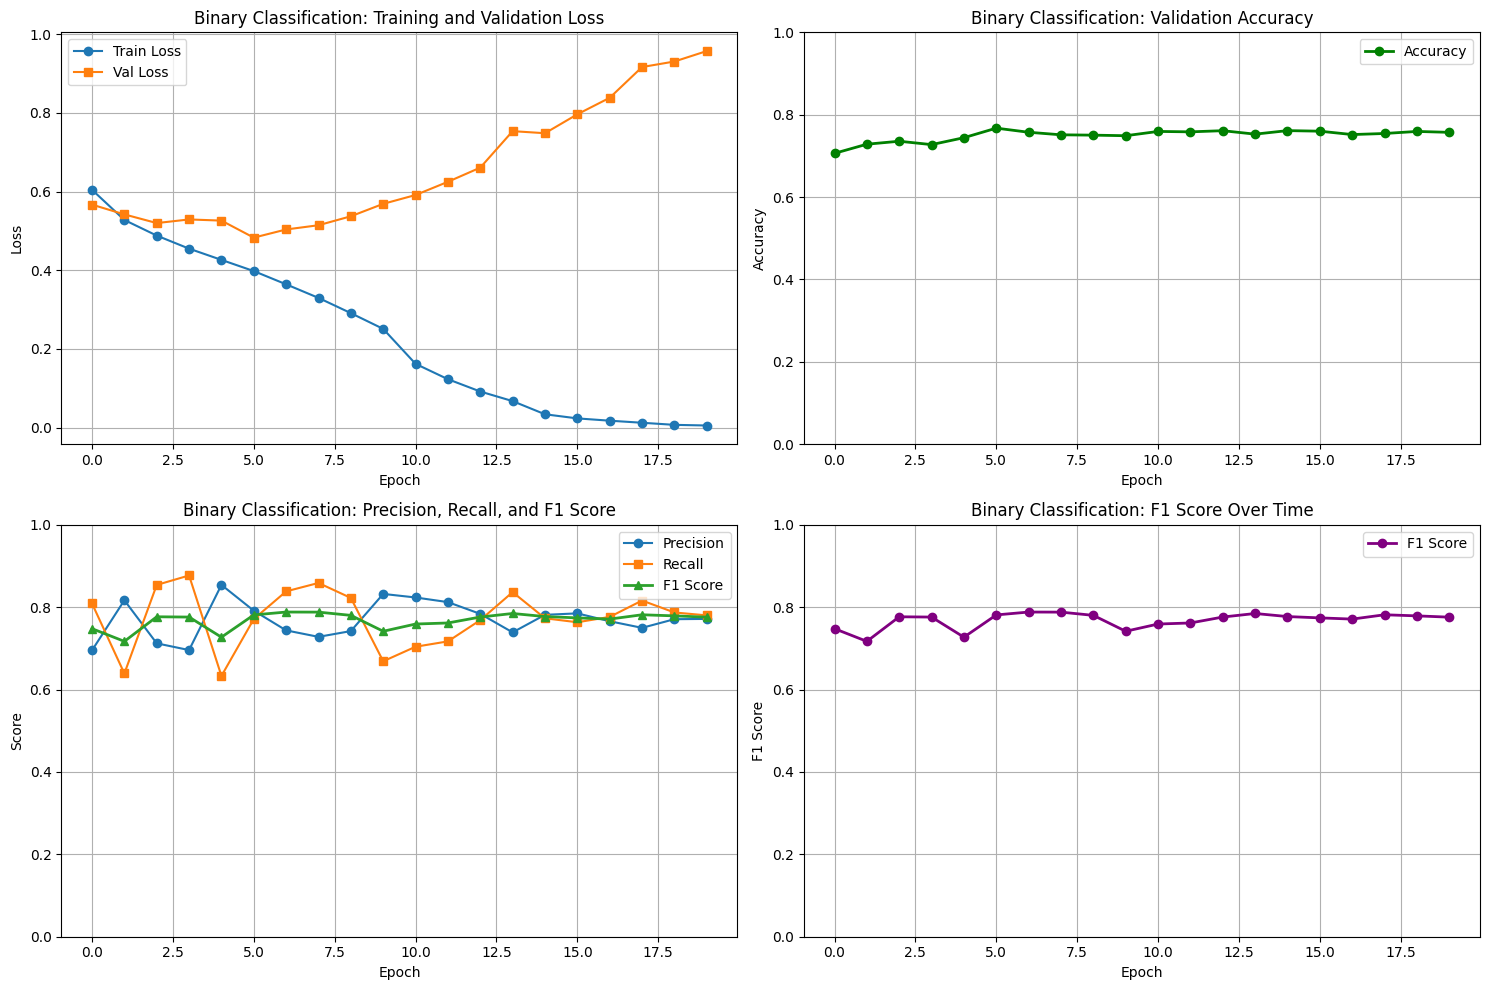


BINARY CLASSIFICATION FINAL RESULTS
Best F1 Score: 0.7883
Final Accuracy: 0.7572
Final Precision: 0.7716
Final Recall: 0.7802
Final F1: 0.7758


In [17]:
# Plot binary classification training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(binary_history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(binary_history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Binary Classification: Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(binary_history['val_accuracy'], label='Accuracy', linewidth=2, marker='o', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Binary Classification: Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)
axes[0, 1].set_ylim([0.0, 1.0])

# Precision, Recall, F1
axes[1, 0].plot(binary_history['val_precision'], label='Precision', marker='o')
axes[1, 0].plot(binary_history['val_recall'], label='Recall', marker='s')
axes[1, 0].plot(binary_history['val_f1'], label='F1 Score', marker='^', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Binary Classification: Precision, Recall, and F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True)
axes[1, 0].set_ylim([0.0, 1.0])

# F1 Score (larger view)
axes[1, 1].plot(binary_history['val_f1'], label='F1 Score', marker='o', linewidth=2, color='purple')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Binary Classification: F1 Score Over Time')
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].set_ylim([0.0, 1.0])

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("BINARY CLASSIFICATION FINAL RESULTS")
print("="*80)
print(f"Best F1 Score: {best_binary_val_f1:.4f}")
print(f"Final Accuracy: {binary_history['val_accuracy'][-1]:.4f}")
print(f"Final Precision: {binary_history['val_precision'][-1]:.4f}")
print(f"Final Recall: {binary_history['val_recall'][-1]:.4f}")
print(f"Final F1: {binary_history['val_f1'][-1]:.4f}")